In [144]:
import matplotlib.pyplot as plt

In [145]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [146]:
def plotStats( X, plots, xLabel, yLabel, title, log_scale = False, i = 0, ylim = -1 ):

    for label, plot in plots:
        if( i == 0 ):
            plt.plot(X, plot, label=label )
        else:
            plt.plot(X[:i], plot[:i], label=label)

    if( log_scale ):
        plt.yscale( "log" )
        plt.ylabel( yLabel + " (Log Scaled)" )
    else:
        if( ylim > 0 ):
            plt.ylim(0, ylim)
        plt.ylabel(yLabel)
    plt.grid()
    plt.xlabel(xLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

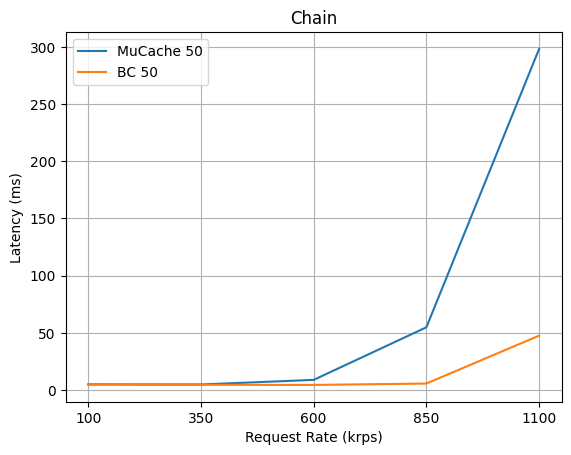

In [8]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-1hop-zmq.json" )
_, mucache_out = getStats( "chain-1hop-zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         #["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],]
         #["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False )

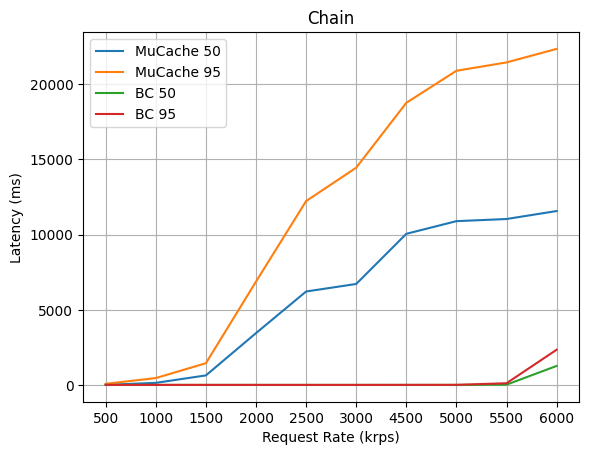

In [15]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-1-hop-redis-improvement.json" )
_, mucache_out = getStats( "chain-1-hop-redis-improvement.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False )

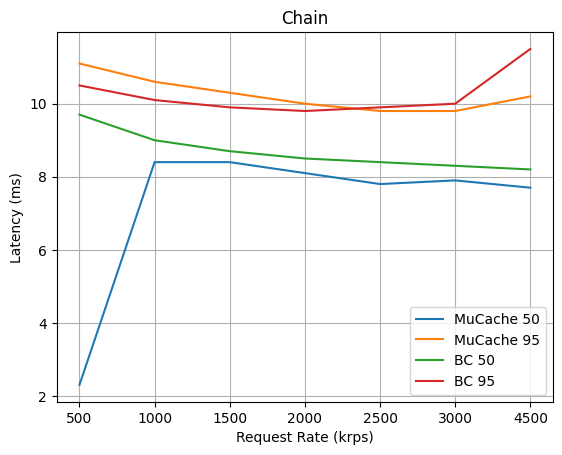

In [23]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "chain-baseline-1hop-redis-cache-improvement.json" )
_, mucache_out = getStats( "chain-1hop-redis-cache-improvement.json" )

plots = [["MuCache 50", mucache_out["50"][:-3]],
         ["MuCache 95", mucache_out["95"][:-3]],
         ["BC 50", bc_out["50"][:-3]],
         ["BC 95", bc_out["95"][:-3]]]

plotStats( x[:-3], plots, "Request Rate (krps)", "Latency (ms)", "Chain", False )

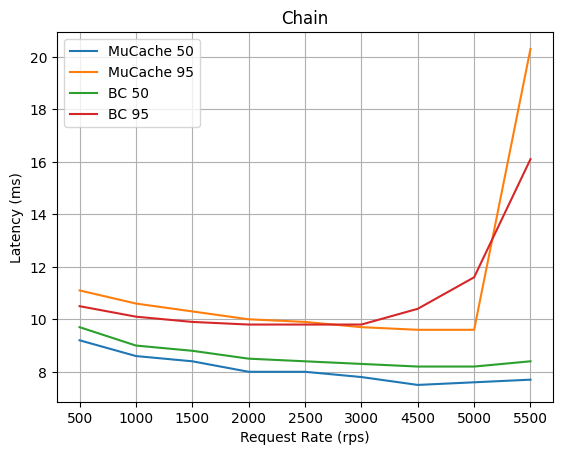

In [29]:
# Chain but increased resources for both redis and cache for 1hop and 8
# Interestingly, latency decreases as RPS goes up, in addition, spike in latency occurs later on.
x, bc_out = getStats( "chain-baseline-1hop-redis-cache-improv-8proc.json" )
_, mucache_out = getStats( "chain-1hop-redis-cache-improv-8proc.json" )

plots = [["MuCache 50", mucache_out["50"][:-1]],
         ["MuCache 95", mucache_out["95"][:-1]],
         ["BC 50", bc_out["50"][:-1]],
         ["BC 95", bc_out["95"][:-1]]]

plotStats( x[:-1], plots, "Request Rate (rps)", "Latency (ms)", "Chain", False )

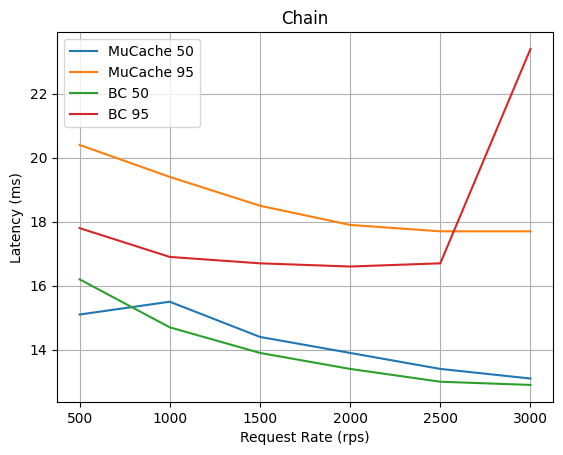

In [45]:
# Chain but increased resources for both redis and cache for 1hop and 8
# Interestingly, latency decreases as RPS goes up, in addition, spike in latency occurs later on.
x, bc_out = getStats( "chain-baseline-4hop-redis-cache-improv.json" )
_, mucache_out = getStats( "chain-4hop-redis-cache-improv.json" )

plots = [["MuCache 50", mucache_out["50"][:-4]],
         ["MuCache 95", mucache_out["95"][:-4]],
         ["BC 50", bc_out["50"][:-4]],
         ["BC 95", bc_out["95"][:-4]]]

plotStats( x[:-4], plots, "Request Rate (rps)", "Latency (ms)", "Chain", False )

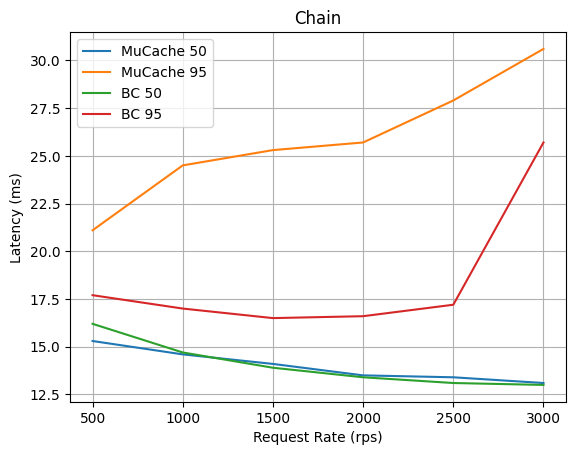

In [49]:
# Chain but increased resources for both redis and cache for 1hop and 8
# with additional cm resources, 
# Does worse?
x, bc_out = getStats( "chain-baseline-4hop-redis-cache-cm-improv.json" )
_, mucache_out = getStats( "chain-4hop-redis-cache-cm-improv.json" )

plots = [["MuCache 50", mucache_out["50"][:-4]],
         ["MuCache 95", mucache_out["95"][:-4]],
         ["BC 50", bc_out["50"][:-4]],
         ["BC 95", bc_out["95"][:-4]]]

plotStats( x[:-4], plots, "Request Rate (rps)", "Latency (ms)", "Chain", False )

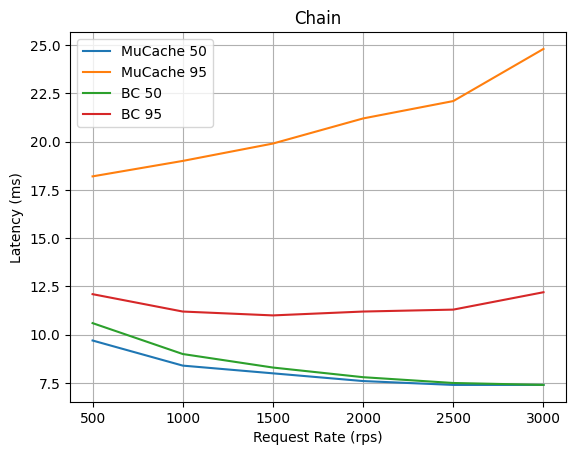

In [50]:
# Chain but increased resources for both redis and cache for 1hop and 8
# with additional cm resources, 
# Does worse?
x, bc_out = getStats( "chain-baseline-4hop-redis-cache-cm-improv-4proc.json" )
_, mucache_out = getStats( "chain-4hop-redis-cache-cm-improv-4proc.json" )

plots = [["MuCache 50", mucache_out["50"][:-4]],
         ["MuCache 95", mucache_out["95"][:-4]],
         ["BC 50", bc_out["50"][:-4]],
         ["BC 95", bc_out["95"][:-4]]]

plotStats( x[:-4], plots, "Request Rate (rps)", "Latency (ms)", "Chain", False )

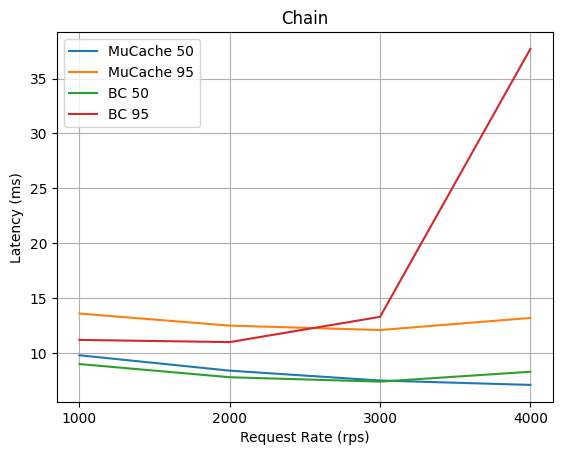

In [55]:
# Chain but increased resources for both redis and cache for 1hop and 8
# with additional cm resources, 
# Does worse?
x, bc_out = getStats( "chain-baseline-4hop-redis-cache-rev-cm-4proc.json" )
_, mucache_out = getStats( "chain-4hop-redis-cache-rev-cm-4proc.json" )
i = 2

plots = [["MuCache 50", mucache_out["50"][:-i]],
         ["MuCache 95", mucache_out["95"][:-i]],
         ["BC 50", bc_out["50"][:-i]],
         ["BC 95", bc_out["95"][:-i]]]

plotStats( x[:-i], plots, "Request Rate (rps)", "Latency (ms)", "Chain", False )

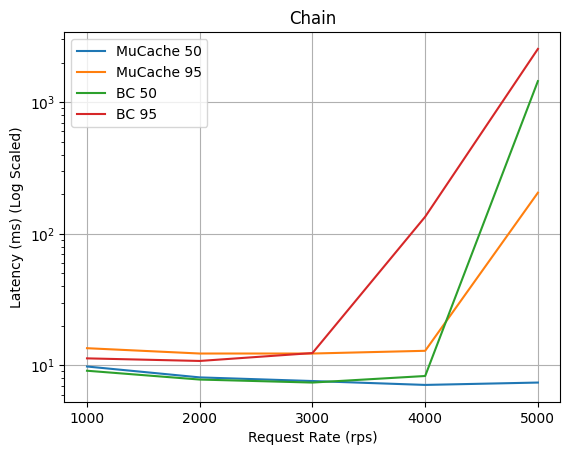

In [70]:
# Chain but increased resources for both redis and cache for 1hop and 8
# with additional cm resources, 
# Does worse?
x, bc_out = getStats( "chain-baseline-4hop-redis-cache-app-4proc.json" )
_, mucache_out = getStats( "chain-4hop-redis-cache-app-4proc.json" )
i = 1

plots = [["MuCache 50", mucache_out["50"][:-i]],
         ["MuCache 95", mucache_out["95"][:-i]],
         ["BC 50", bc_out["50"][:-i]],
         ["BC 95", bc_out["95"][:-i]]]

plotStats( x[:-i], plots, "Request Rate (rps)", "Latency (ms)", "Chain", True )

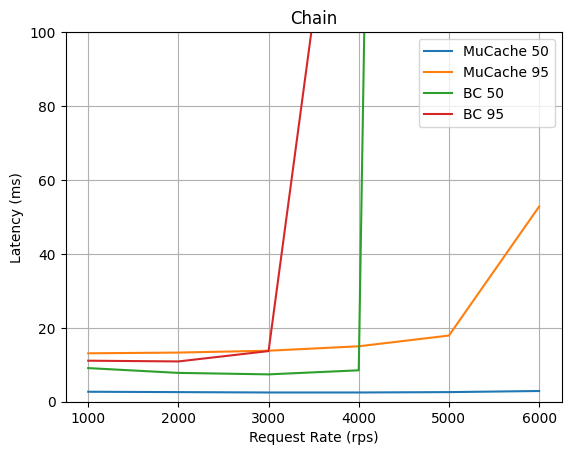

In [121]:
# Chain but increased resources for both redis and cache for 1hop and 8
# with additional cm resources, 
# Does worse?
x, bc_out = getStats( "chain-baseline-4hop-redis-cache-app-cm-4proc.json" )
_, mucache_out = getStats( "chain-4hop-redis-cache-app-cm-4proc.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Chain", ylim=100 )

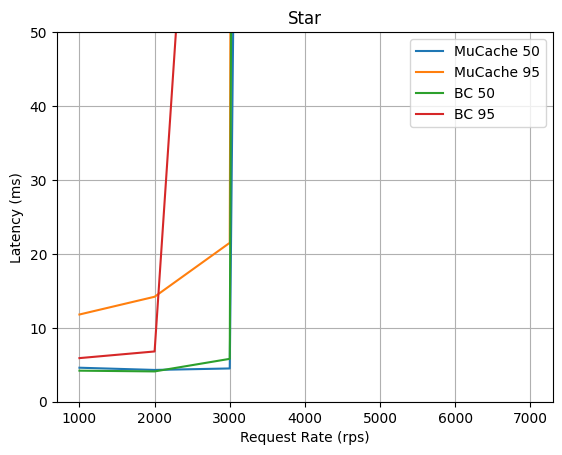

In [123]:
# Star with resources
x, bc_out = getStats( "star-baseline-resource-increase.json" )
_, mucache_out = getStats( "star-resource-increase.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Star", i=0, ylim=50 )

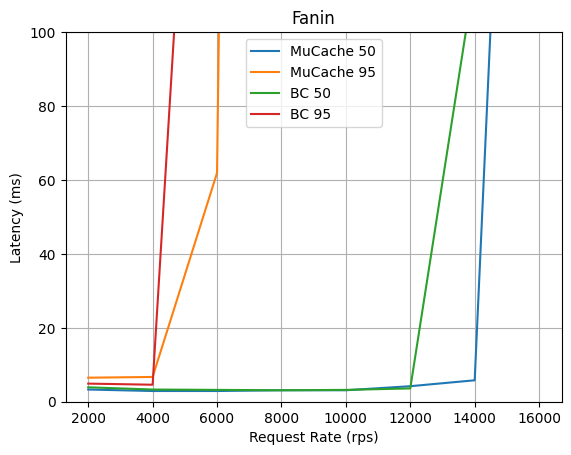

In [122]:
# Star with resources
x, bc_out = getStats( "fanin-baseline-resource-increase.json" )
_, mucache_out = getStats( "fanin-resource-increase.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Fanin", ylim=100 )

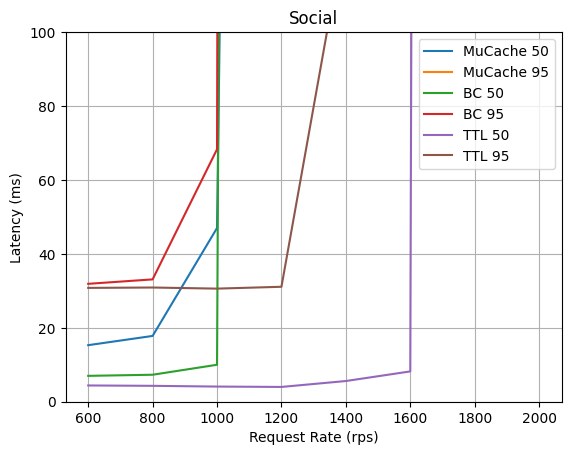

In [130]:
# Social with resources
x, bc_out = getStats( "social-baseline.json" )
_, mucache_out = getStats( "social.json" )
_, ttl_out = getStats( "social-upper.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim=100 )

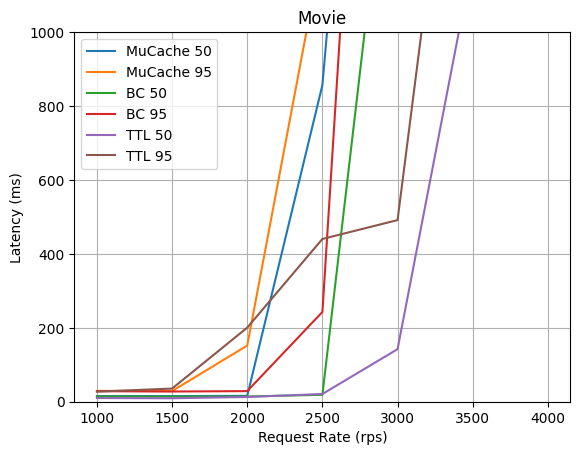

In [136]:
# Movie with resources
x, bc_out = getStats( "movie-baseline-resource-increase.json" )
_, mucache_out = getStats( "movie-resource-increase.json" )
_, ttl_out = getStats( "movie-upper-resource-increase.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim=1000 )

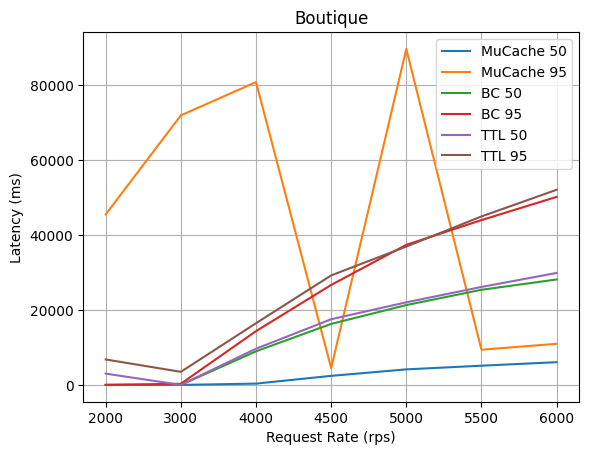

In [139]:
# Boutique with resources
x, bc_out = getStats( "boutique-baseline-1mi.json" )
_, mucache_out = getStats( "boutique-1mi.json" )
_, ttl_out = getStats( "boutique-upper-1mi.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique" )

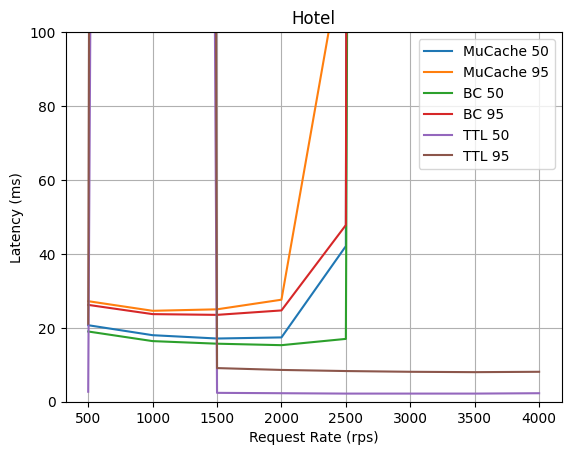

In [143]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-1m.json" )
_, mucache_out = getStats( "hotel-1m.json" )
_, ttl_out = getStats( "hotel-upper-1m.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )